### **Download dataset**

In [1]:
# @title
# =========================================================
# DOWNLOAD DATASET ZIP TỪ GOOGLE DRIVE
# =========================================================
!gdown --id 1WcClLmdpOZZPZiOjKxPqg5Q7OuJWMBwM

# =========================================================
# UNZIP DATASET
# =========================================================

!unzip -q FracAtlas_FS.zip

# =========================================================
# KIỂM TRA DATASET
# =========================================================
print("\nDATASET STRUCTURE:")
!ls FracAtlas_FS

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1WcClLmdpOZZPZiOjKxPqg5Q7OuJWMBwM
From (redirected): https://drive.google.com/uc?id=1WcClLmdpOZZPZiOjKxPqg5Q7OuJWMBwM&confirm=t&uuid=9a833e2d-cc0b-432d-8dee-a78ce3754b29
To: /kaggle/working/FracAtlas_FS.zip
100%|████████████████████████████████████████| 871M/871M [00:11<00:00, 73.0MB/s]

DATASET STRUCTURE:
Annotations  dataset.csv  images  masks  test.txt  train.txt  val.txt


### **Import & Install**

In [2]:
# @title
# Cài đặt các thư viện cần thiết
!pip install openpyxl torchmetrics -q

import os
import pandas as pd
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import copy

# Kiểm tra GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Đang sử dụng thiết bị: {device}")

Đang sử dụng thiết bị: cuda


### **Dataloader**

In [3]:
import os
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms

# Cấu hình đường dẫn
DATA_DIR = '/kaggle/working/FracAtlas_FS'
IMAGES_DIR = os.path.join(DATA_DIR, 'images')
CSV_PATH = os.path.join(DATA_DIR, 'dataset.csv')  # Đổi tên biến cho đúng bản chất CSV

# Hàm đọc file .txt chứa danh sách tên ảnh (không đuôi)
def load_split_from_txt(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        return [line.strip() for line in f if line.strip()]

# 1. Đọc danh sách ảnh từ các file txt
train_ids = load_split_from_txt(os.path.join(DATA_DIR, 'train.txt'))
val_ids = load_split_from_txt(os.path.join(DATA_DIR, 'val.txt'))
test_ids = load_split_from_txt(os.path.join(DATA_DIR, 'test.txt'))

# 2. SỬA: Đọc file bằng read_csv thay vì read_excel
df = pd.read_csv(CSV_PATH)

# Chuẩn hóa cột tên ảnh về dạng KHÔNG ĐUÔI để khớp với file txt
df['image_id_clean'] = df['image_id'].str.replace('.jpeg', '', regex=False).str.replace('.jpg', '', regex=False)

# Lọc dataframe theo danh sách id đã đọc từ file txt (dựa trên cột đã xóa đuôi)
train_df = df[df['image_id_clean'].isin(train_ids)].reset_index(drop=True)
val_df = df[df['image_id_clean'].isin(val_ids)].reset_index(drop=True)
test_df = df[df['image_id_clean'].isin(test_ids)].reset_index(drop=True)

print(f"Số lượng tập Train: {len(train_df)}")
print(f"Số lượng tập Val:   {len(val_df)}")
print(f"Số lượng tập Test:  {len(test_df)}")

# 3. Định nghĩa Dataset class
class FracAtlasDataset(Dataset): # Đổi tên cho hợp với dataset mới
    def __init__(self, dataframe, img_dir, transform=None):
        self.dataframe = dataframe
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = self.dataframe.loc[idx, 'image_id'] 
        img_name = img_name.replace('.jpg', '.png')
        img_path = os.path.join(self.img_dir, img_name)

        # Mở ảnh và chuyển về RGB
        image = Image.open(img_path).convert('RGB')
        label = float(self.dataframe.loc[idx, 'fractured'])

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor([label], dtype=torch.float32)

# 4. Data Augmentation & Transforms 
train_transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.RandomHorizontalFlip(p=0.5), 
    transforms.RandomRotation(degrees=15),  
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = val_transform

# 5. Tạo DataLoader
BATCH_SIZE = 16
train_dataset = FracAtlasDataset(train_df, IMAGES_DIR, transform=train_transform)
val_dataset = FracAtlasDataset(val_df, IMAGES_DIR, transform=val_transform)
test_dataset = FracAtlasDataset(test_df, IMAGES_DIR, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

Số lượng tập Train: 3265
Số lượng tập Val:   409
Số lượng tập Test:  409


### **Train**

In [4]:
import torch
import torch.nn as nn
from torchvision import models
import os

# --- 1. CẤU HÌNH SIÊU THAM SỐ ---
Lr1 = 1e-4        # LR cho giai đoạn Transfer learning
Lr2 = 1e-5      # LR cho giai đoạn Finetune
EPOCHS = 25       # Số epoch chạy Transfer learning
TOTAL_EPOCHS = 125      # Tổng số epoch dự kiến
PATIENCE = 15           # Early stopping

# Đường dẫn lưu 2 checkpoint độc lập
SAVE_PATH_LOSS = '/kaggle/working/checkpoint/best_loss_efficientnet_b3.pth'
SAVE_PATH_ACC = '/kaggle/working/checkpoint/best_acc_efficientnet_b3.pth'
SAVE_DIR = '/kaggle/working/checkpoint'
os.makedirs(SAVE_DIR, exist_ok=True)

# --- 2. KHỞI TẠO MÔ HÌNH ---
model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 1) # Phân loại nhị phân
model = model.to(device)

# Tính toán trọng số dựa trên số lượng mẫu thực tế (717 ảnh fractured và 3366 ảnh non fractured)
pos_weight = torch.tensor([3366 / 717], dtype=torch.float32).to(device)

# Truyền pos_weight vào hàm loss
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# --- 3. LỚP HỖ TRỢ DUAL EARLY STOPPING ---
class DualEarlyStopping:
    def __init__(self, patience=15, path_loss='best_loss.pth', path_acc='best_acc.pth'):
        self.patience = patience
        self.best_loss = float('inf')
        self.best_acc = float('-inf')
        self.counter = 0
        self.path_loss = path_loss
        self.path_acc = path_acc
        self.early_stop = False

    def __call__(self, val_loss, val_acc, model):
        # 1. Lưu checkpoint theo Loss tốt nhất (Chỉ lưu, không tính dừng sớm)
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            torch.save(model.state_dict(), self.path_loss)

        # 2. Theo dõi Accuracy để quyết định checkpoint và kích hoạt Dừng Sớm
        if val_acc > self.best_acc:
            self.best_acc = val_acc
            torch.save(model.state_dict(), self.path_acc)
            self.counter = 0  # Reset bộ đếm khi Acc tăng
        else:
            self.counter += 1 # Tăng bộ đếm nếu Acc không tăng
            print(f"   [EarlyStopping] Acc không tăng. Đếm: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True

early_stopping = DualEarlyStopping(patience=PATIENCE, path_loss=SAVE_PATH_LOSS, path_acc=SAVE_PATH_ACC)

# --- 4. HÀM HUẤN LUYỆN CHO 1 EPOCH ---
def run_epoch(epoch, model, loader, optimizer, criterion, is_train=True):
    if is_train:
        model.train()
        for m in model.modules():
            if isinstance(m, nn.BatchNorm2d):
                m.eval()
    else:
        model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.set_grad_enabled(is_train):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device).float()

            if is_train:
                optimizer.zero_grad()

            outputs = model(images).view(-1)
            labels = labels.view(-1)
            loss = criterion(outputs, labels)

            if is_train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)

            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(loader.dataset)
    acc = correct / total

    return avg_loss, acc


# --- 5. BẮT ĐẦU HUẤN LUYỆN ---
# GIAI ĐOẠN 1: FREEZE BACKBONE (Warmup)
print(f"--- GIAI ĐOẠN 1: FREEZE BACKBONE ({EPOCHS} Epochs) ---")
for param in model.features.parameters():
    param.requires_grad = False

optimizer = torch.optim.AdamW(model.classifier.parameters(), lr=Lr1)

for epoch in range(EPOCHS):
    train_loss, train_acc = run_epoch(epoch, model, train_loader, optimizer, criterion, is_train=True)
    val_loss, val_acc = run_epoch(epoch, model, val_loader, None, criterion, is_train=False)
    print(f"Epoch {epoch+1}: Train_loss={train_loss:.4f} | Val_loss={val_loss:.4f} | Train_acc={train_acc:.4f} | Val_acc={val_acc:.4f}")

    # Gọi hàm kiểm tra song song loss và acc
    early_stopping(val_loss, val_acc, model)
    if early_stopping.early_stop:
        print("Kích hoạt Early Stopping tại Giai đoạn 1!")
        break

# GIAI ĐOẠN 2: UNFREEZE ALL (Finetuning)
print(f"\n--- GIAI ĐOẠN 2: UNFREEZE ALL & FINETUNE ---")
if not early_stopping.early_stop:
    for param in model.parameters():
        param.requires_grad = True

    for module in model.modules():
        if isinstance(module, nn.BatchNorm2d):
            for param in module.parameters():
                param.requires_grad = False

    optimizer = torch.optim.AdamW(model.parameters(), lr=Lr2)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=(TOTAL_EPOCHS - EPOCHS))

    FINETUNE_EPOCHS = TOTAL_EPOCHS - EPOCHS
    for epoch in range(FINETUNE_EPOCHS):
        train_loss, train_acc = run_epoch(epoch, model, train_loader, optimizer, criterion, is_train=True)
        val_loss, val_acc = run_epoch(epoch, model, val_loader, None, criterion, is_train=False)
        scheduler.step()

        print(f"Epoch {epoch+1}/{FINETUNE_EPOCHS}: Train_loss={train_loss:.4f} | Val_loss={val_loss:.4f} | Train_acc={train_acc:.4f} | Val_acc={val_acc:.4f}")

        # Tiếp tục gọi hàm kiểm tra song song cho giai đoạn 2
        early_stopping(val_loss, val_acc, model)
        if early_stopping.early_stop:
            print("Kích hoạt Early Stopping tại Giai đoạn 2!")
            break

print("Hoàn thành huấn luyện. Hai file trọng số tốt nhất đã được cập nhật thành công!")

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 148MB/s]


--- GIAI ĐOẠN 1: FREEZE BACKBONE (25 Epochs) ---
Epoch 1: Train_loss=1.1329 | Val_loss=1.0828 | Train_acc=0.6119 | Val_acc=0.7262
Epoch 2: Train_loss=1.0803 | Val_loss=1.0340 | Train_acc=0.6643 | Val_acc=0.8166
Epoch 3: Train_loss=1.0413 | Val_loss=0.9965 | Train_acc=0.7237 | Val_acc=0.8362
Epoch 4: Train_loss=1.0044 | Val_loss=0.9649 | Train_acc=0.7351 | Val_acc=0.8386
Epoch 5: Train_loss=0.9792 | Val_loss=0.9436 | Train_acc=0.7142 | Val_acc=0.8484
Epoch 6: Train_loss=0.9599 | Val_loss=0.9228 | Train_acc=0.7461 | Val_acc=0.8557
Epoch 7: Train_loss=0.9371 | Val_loss=0.9053 | Train_acc=0.7406 | Val_acc=0.8460
   [EarlyStopping] Acc không tăng. Đếm: 1/15
Epoch 8: Train_loss=0.9225 | Val_loss=0.8898 | Train_acc=0.7391 | Val_acc=0.8582
Epoch 9: Train_loss=0.9033 | Val_loss=0.8784 | Train_acc=0.7544 | Val_acc=0.8606
Epoch 10: Train_loss=0.8948 | Val_loss=0.8673 | Train_acc=0.7663 | Val_acc=0.8582
   [EarlyStopping] Acc không tăng. Đếm: 1/15
Epoch 11: Train_loss=0.8986 | Val_loss=0.8548 | Tr

### **Test best loss**


Bắt đầu đánh giá trên tập Test theo tiêu chuẩn Y tế...
--------------------------------------------------
KẾT QUẢ ĐÁNH GIÁ Y KHOA (EFFICIENTNETB3):
1. Top-1 Accuracy (Độ chính xác) : 88.26%
2. AUC-ROC Score                  : 0.9132
3. Precision (Giá trị dự báo (+)) : 65.38%
4. Specificity (Độ đặc hiệu)      : 91.99%  (Khả năng loại trừ KHÔNG BỆNH)
5. Recall / Sensitivity (Độ nhạy) : 70.83%  (Khả năng phát hiện BỆNH)
6. Số lượng tham số mạng          : 10,697,769
7. Dung lượng file trọng số (.pth): 41.35 MB
--------------------------------------------------
Bổ sung chỉ số NPV (Dự báo (-))   : 93.66%
--------------------------------------------------


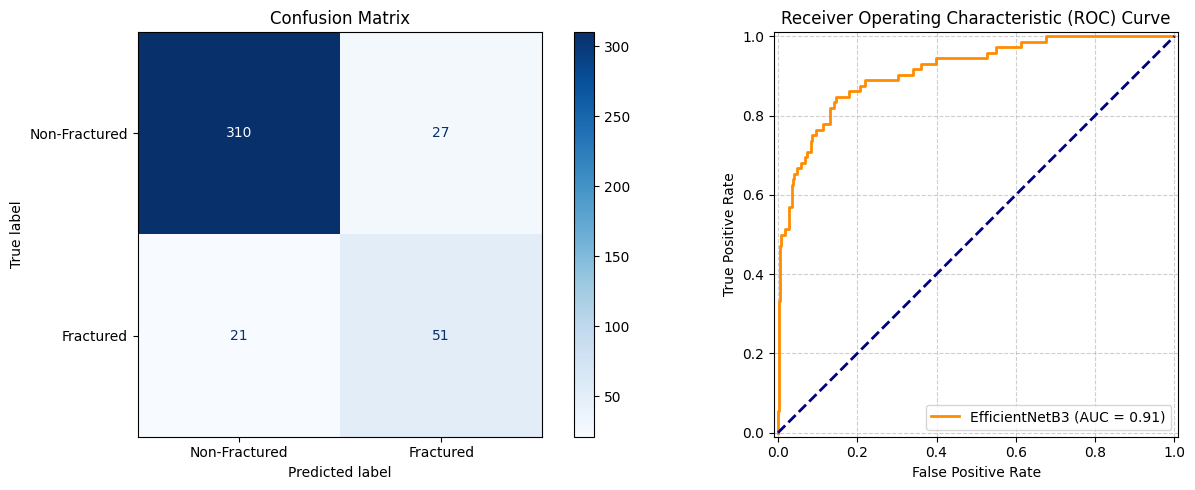

In [5]:
# @title
# =========================================================
# 6. ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST THEO TIÊU CHUẨN Y KHOA
# =========================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    RocCurveDisplay,
    accuracy_score
)
import torch
import os

print("\nBắt đầu đánh giá trên tập Test theo tiêu chuẩn Y tế...")

# 1. Khởi tạo lại cấu trúc mô hình và nạp trọng số PyTorch (.pth)
model = models.efficientnet_b3(weights=None) # Không cần tải lại weights gốc ImageNet
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 1)
model = model.to(device)

best_model_path = '/kaggle/working/checkpoint/best_loss_efficientnet_b3.pth'
if os.path.exists(best_model_path):
    model.load_state_dict(torch.load(best_model_path, map_location='cpu'))
    file_suffix = "(.pth)"
    model_size_bytes = os.path.getsize(best_model_path)
    model_size_mb = model_size_bytes / (1024 * 1024)
else:
    file_suffix = "(Chưa lưu checkpoint)"
    model_size_mb = 0.0

model.eval()

# 2. Thu thập xác xuất và nhãn thực tế từ test_loader
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device).float()

        # Ép phẳng về mảng 1 chiều ngay từ đầu
        outputs = model(images).view(-1)
        labels = labels.view(-1)

        # Tính xác suất bằng Sigmoid
        probs = torch.sigmoid(outputs)

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Chuyển đổi sang mảng Numpy 1D phục vụ tính toán các chỉ số
y_prob = np.array(all_probs)
y_true = np.array(all_labels).astype(int)
y_pred = (y_prob > 0.5).astype(int) # Ngưỡng phân loại bệnh 50%

# 3. Tính toán Ma trận nhầm lẫn (Confusion Matrix)
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

# 4. Tính toán các chỉ số y tế theo đúng thứ tự yêu cầu
top1_accuracy = accuracy_score(y_true, y_pred)
auc_score = roc_auc_score(y_true, y_prob)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0       # Chính là PPV
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0     # Độ đặc hiệu
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0     # Độ nhạy / Recall
npv = tn / (tn + fn) if (tn + fn) > 0 else 0             # Giá trị dự báo âm tính

# Đếm tổng số lượng tham số mạng trong PyTorch
total_params = sum(p.numel() for p in model.parameters())

# --- IN KẾT QUẢ ĐÁNH GIÁ CHI TIẾT THEO ĐÚNG THỨ TỰ CỦA KÉRAS MẪU ---
print("-" * 50)
print(f"KẾT QUẢ ĐÁNH GIÁ Y KHOA (EFFICIENTNETB3):")
print(f"1. Top-1 Accuracy (Độ chính xác) : {top1_accuracy*100:.2f}%")
print(f"2. AUC-ROC Score                  : {auc_score:.4f}")
print(f"3. Precision (Giá trị dự báo (+)) : {precision*100:.2f}%")
print(f"4. Specificity (Độ đặc hiệu)      : {specificity*100:.2f}%  (Khả năng loại trừ KHÔNG BỆNH)")
print(f"5. Recall / Sensitivity (Độ nhạy) : {sensitivity*100:.2f}%  (Khả năng phát hiện BỆNH)")
print(f"6. Số lượng tham số mạng          : {total_params:,}")
print(f"7. Dung lượng file trọng số {file_suffix}: {model_size_mb:.2f} MB")
print("-" * 50)
print(f"Bổ sung chỉ số NPV (Dự báo (-))   : {npv*100:.2f}%")
print("-" * 50)

# 5. TRỰC QUAN HÓA ĐỒ THỊ ĐÔI (CONFUSION MATRIX & ROC CURVE)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Đồ thị 1: Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Fractured", "Fractured"])
disp.plot(cmap='Blues', ax=ax[0])
ax[0].set_title("Confusion Matrix")

# Đồ thị 2: ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_disp = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc_score, estimator_name='EfficientNetB3')
roc_disp.plot(ax=ax[1], color='darkorange', lw=2)
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Đường chéo ngẫu nhiên
ax[1].set_title("Receiver Operating Characteristic (ROC) Curve")
ax[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### **Test best acc**


Bắt đầu đánh giá trên tập Test theo tiêu chuẩn Y tế...
--------------------------------------------------
KẾT QUẢ ĐÁNH GIÁ Y KHOA (EFFICIENTNETB3):
1. Top-1 Accuracy (Độ chính xác) : 89.73%
2. AUC-ROC Score                  : 0.8951
3. Precision (Giá trị dự báo (+)) : 75.00%
4. Specificity (Độ đặc hiệu)      : 95.55%  (Khả năng loại trừ KHÔNG BỆNH)
5. Recall / Sensitivity (Độ nhạy) : 62.50%  (Khả năng phát hiện BỆNH)
6. Số lượng tham số mạng          : 10,697,769
7. Dung lượng file trọng số (.pth): 41.35 MB
--------------------------------------------------
Bổ sung chỉ số NPV (Dự báo (-))   : 92.26%
--------------------------------------------------


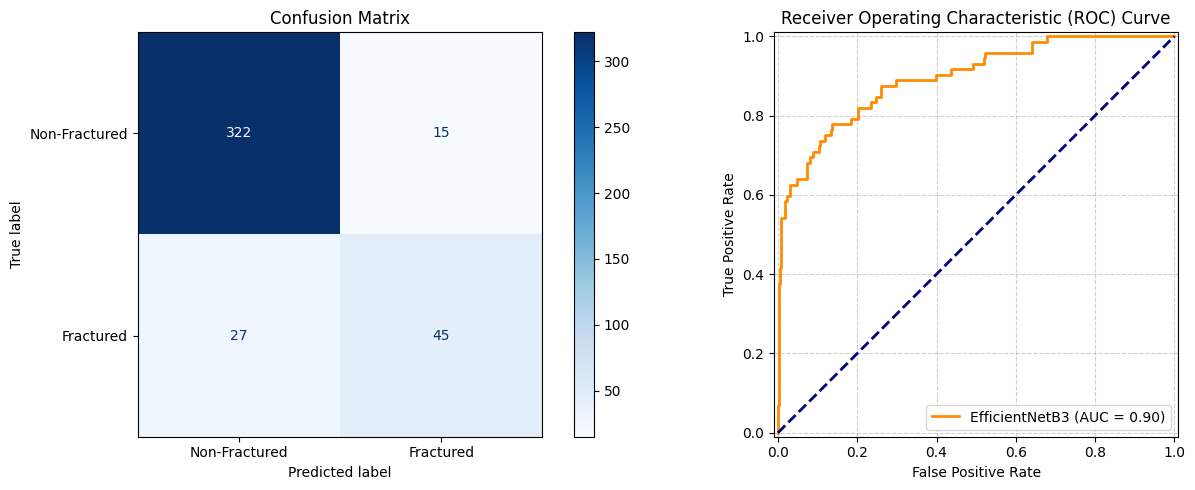

In [6]:
# @title
# =========================================================
# 6. ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST THEO TIÊU CHUẨN Y KHOA
# =========================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    RocCurveDisplay,
    accuracy_score
)
import torch
import os

print("\nBắt đầu đánh giá trên tập Test theo tiêu chuẩn Y tế...")

# 1. Khởi tạo lại cấu trúc mô hình và nạp trọng số PyTorch (.pth)
model = models.efficientnet_b3(weights=None) # Không cần tải lại weights gốc ImageNet
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 1)
model = model.to(device)

best_model_path = '/kaggle/working/checkpoint/best_acc_efficientnet_b3.pth'
if os.path.exists(best_model_path):
    model.load_state_dict(torch.load(best_model_path, map_location='cpu'))
    file_suffix = "(.pth)"
    model_size_bytes = os.path.getsize(best_model_path)
    model_size_mb = model_size_bytes / (1024 * 1024)
else:
    file_suffix = "(Chưa lưu checkpoint)"
    model_size_mb = 0.0

model.eval()

# 2. Thu thập xác xuất và nhãn thực tế từ test_loader
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device).float()

        # Ép phẳng về mảng 1 chiều ngay từ đầu
        outputs = model(images).view(-1)
        labels = labels.view(-1)

        # Tính xác suất bằng Sigmoid
        probs = torch.sigmoid(outputs)

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Chuyển đổi sang mảng Numpy 1D phục vụ tính toán các chỉ số
y_prob = np.array(all_probs)
y_true = np.array(all_labels).astype(int)
y_pred = (y_prob > 0.5).astype(int) # Ngưỡng phân loại bệnh 50%

# 3. Tính toán Ma trận nhầm lẫn (Confusion Matrix)
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

# 4. Tính toán các chỉ số y tế theo đúng thứ tự yêu cầu
top1_accuracy = accuracy_score(y_true, y_pred)
auc_score = roc_auc_score(y_true, y_prob)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0       # Chính là PPV
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0     # Độ đặc hiệu
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0     # Độ nhạy / Recall
npv = tn / (tn + fn) if (tn + fn) > 0 else 0             # Giá trị dự báo âm tính

# Đếm tổng số lượng tham số mạng trong PyTorch
total_params = sum(p.numel() for p in model.parameters())

# --- IN KẾT QUẢ ĐÁNH GIÁ CHI TIẾT THEO ĐÚNG THỨ TỰ CỦA KÉRAS MẪU ---
print("-" * 50)
print(f"KẾT QUẢ ĐÁNH GIÁ Y KHOA (EFFICIENTNETB3):")
print(f"1. Top-1 Accuracy (Độ chính xác) : {top1_accuracy*100:.2f}%")
print(f"2. AUC-ROC Score                  : {auc_score:.4f}")
print(f"3. Precision (Giá trị dự báo (+)) : {precision*100:.2f}%")
print(f"4. Specificity (Độ đặc hiệu)      : {specificity*100:.2f}%  (Khả năng loại trừ KHÔNG BỆNH)")
print(f"5. Recall / Sensitivity (Độ nhạy) : {sensitivity*100:.2f}%  (Khả năng phát hiện BỆNH)")
print(f"6. Số lượng tham số mạng          : {total_params:,}")
print(f"7. Dung lượng file trọng số {file_suffix}: {model_size_mb:.2f} MB")
print("-" * 50)
print(f"Bổ sung chỉ số NPV (Dự báo (-))   : {npv*100:.2f}%")
print("-" * 50)

# 5. TRỰC QUAN HÓA ĐỒ THỊ ĐÔI (CONFUSION MATRIX & ROC CURVE)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Đồ thị 1: Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Fractured", "Fractured"])
disp.plot(cmap='Blues', ax=ax[0])
ax[0].set_title("Confusion Matrix")

# Đồ thị 2: ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_disp = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc_score, estimator_name='EfficientNetB3')
roc_disp.plot(ax=ax[1], color='darkorange', lw=2)
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Đường chéo ngẫu nhiên
ax[1].set_title("Receiver Operating Characteristic (ROC) Curve")
ax[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()